<a href="https://colab.research.google.com/github/likhithaganga9/adaptive-prompt-optimization-sd15/blob/main/Adaptive_prompt_optimization_stablediffusion_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install diffusers transformers accelerate safetensors sentencepiece

In [ ]:
import torch
import re
from diffusers import StableDiffusionPipeline
from PIL import Image
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
)

pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [ ]:
def refine_prompt(prompt):
    quality = "masterpiece, best quality, ultra detailed, highly realistic, 8k"
    return quality + ", " + prompt

def negative_prompt():
    return (
        "low quality, blurry, bad anatomy, watermark, "
        "text, logo, deformed, duplicate"
    )

In [ ]:
def guidance_scale(prompt):
    length = len(prompt.split())

    if length < 8:
        return 9.0
    elif length < 18:
        return 7.5
    else:
        return 6.0

In [ ]:
user_prompt = input("Enter Prompt: ")

original = pipe(
    prompt=user_prompt,
    guidance_scale=7.5
).images[0]
original.save("original.png")

Enter Prompt: A beautiful sunset over a peaceful lake with mountains in the background and birds flying in the sky


  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
new_prompt = refine_prompt(user_prompt)
negative = negative_prompt()
scale = guidance_scale(new_prompt)

optimized = pipe(
    prompt=new_prompt,
    negative_prompt=negative,
    guidance_scale=scale
).images[0]

optimized.save("optimized.png")

  0%|          | 0/50 [00:00<?, ?it/s]

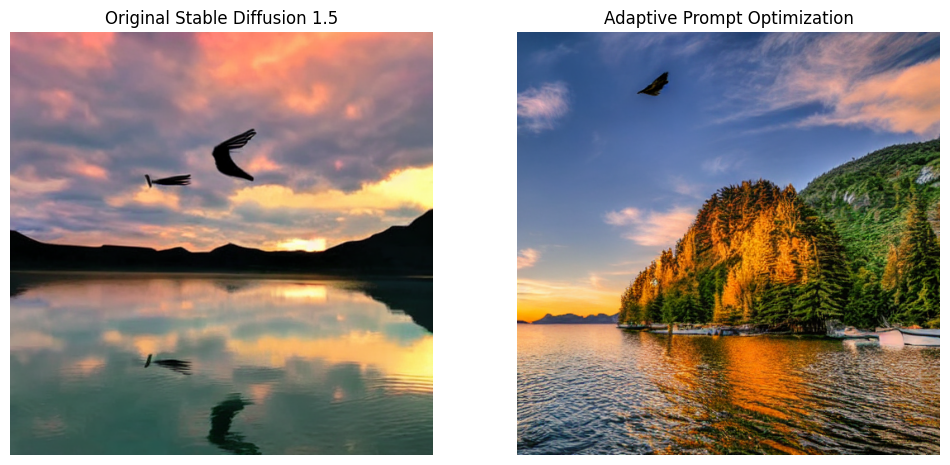

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original Stable Diffusion 1.5")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(optimized)
plt.title("Adaptive Prompt Optimization")
plt.axis("off")

plt.show()

In [ ]:
print("Original Prompt:")
print(user_prompt)

print("\nRefined Prompt:")
print(new_prompt)

print("\nNegative Prompt:")
print(negative)

print("\nSelected Guidance Scale:")
print(scale)

Original Prompt:
A beautiful sunset over a peaceful lake with mountains in the background and birds flying in the sky

Refined Prompt:
masterpiece, best quality, ultra detailed, highly realistic, 8k, A beautiful sunset over a peaceful lake with mountains in the background and birds flying in the sky

Negative Prompt:
low quality, blurry, bad anatomy, watermark, text, logo, deformed, duplicate

Selected Guidance Scale:
6.0
